# Running SCellBOW phenotype algebra on a simulated prostate cancer dataset
> ### There are three molecular subtype - ARAH, ARAL, and NE

In [1]:
import SCellBOW as sb
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

[nltk_data] Downloading package punkt to
[nltk_data]     /home/lmgonzalezb/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/lmgonzalezb/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# SCellBOW Pretrained model

In [3]:
os.chdir("/home/lmgonzalezb/Documents/bc-meta/SCellBow/GBM")

In [4]:
adata_source = sc.read("data/expression/gbm_expr_source.h5ad")
adata_source

AnnData object with n_obs × n_vars = 7517 × 14675
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ribo', 'cell_type', 'sample', 'RNA_snn_res.0.5', 'seurat_clusters'

In [5]:
# preprocessing source data
adata_source.var_names_make_unique()

sc.pp.normalize_total(adata_source, target_sum=1e4)
sc.pp.log1p(adata_source)

sc.pp.highly_variable_genes(
    adata_source, flavor="seurat_v3", n_top_genes=2000, batch_key="sample", subset=True
)

sc.pp.scale(adata_source, max_value=10)
adata_source

/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


AnnData object with n_obs × n_vars = 7517 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ribo', 'cell_type', 'sample', 'RNA_snn_res.0.5', 'seurat_clusters'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'hvg'

Load the survival data

In [6]:
adata_train = sc.read("../TCGA/gbm_survival.h5ad")


In [7]:
adata_train.obs


,subtype,time,status
TCGA-02-0047,GBM,448,1
TCGA-02-0055,GBM,76,1
TCGA-02-2483,GBM,466,0
TCGA-02-2485,GBM,470,0
TCGA-02-2486,GBM,618,1
...,...,...,...
TCGA-76-4927,GBM,535,1
TCGA-76-4928,GBM,94,1
TCGA-76-4929,GBM,111,1
TCGA-76-4931,GBM,279,1


Load the target dataset with VAR score values to compare with the SCellBOW predictions

In [8]:
adata_target = sc.read("data/expression/gbm_expr_target.h5ad")
adata_target.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell,sample,percent.mt,percent.ribo,cell_type,malignancy,study,...,treated,treatment_type,treatment_response,treatment_info,os,pfi,sequencing_tech,genome_assembly,data_pmid,refined_tumor_site
c705476,gbm_nourhan_abdelfattah,14608,4194,AAACCTGAGAAGCCCA-1_1_18,GSM5518596,4.186154,7.985450,Glioma,True,gbm_nourhan_abdelfattah,...,t,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
c705477,gbm_nourhan_abdelfattah,9025,3015,AAAGCAAAGCTGCAAG-1_1_18,GSM5518596,4.349399,8.608373,Glioma,True,gbm_nourhan_abdelfattah,...,t,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
c705478,gbm_nourhan_abdelfattah,11595,3514,AAATGCCCAATTGCTG-1_1_18,GSM5518596,3.504023,8.504399,Glioma,True,gbm_nourhan_abdelfattah,...,t,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
c705479,gbm_nourhan_abdelfattah,3360,1935,AACACGTTCGGCCGAT-1_1_18,GSM5518596,5.526924,2.488004,Glioma,True,gbm_nourhan_abdelfattah,...,t,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
c705480,gbm_nourhan_abdelfattah,7801,2748,AACCGCGGTAGAGCTG-1_1_18,GSM5518596,3.463663,12.069698,Glioma,True,gbm_nourhan_abdelfattah,...,t,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c769366,gbm_nourhan_abdelfattah,4157,2143,TTTGATCGTAGCGCTC-1_44_18,GSM5518639,0.231044,9.976896,Glioma,True,gbm_nourhan_abdelfattah,...,f,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
c769367,gbm_nourhan_abdelfattah,3677,1778,TTTGATCTCTTGGAAC-1_44_18,GSM5518639,9.142857,2.995074,Glioma,True,gbm_nourhan_abdelfattah,...,f,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
c769368,gbm_nourhan_abdelfattah,2175,1214,TTTGGAGTCGTTCGCT-1_44_18,GSM5518639,0.042105,5.557895,Glioma,True,gbm_nourhan_abdelfattah,...,f,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain
c769369,gbm_nourhan_abdelfattah,3991,2140,TTTGGTTCATCGCTAA-1_44_18,GSM5518639,1.622222,8.844444,Glioma,True,gbm_nourhan_abdelfattah,...,f,NaN,NaN,NaN,NaN,NaN,10xv1,grch38,35140215,brain


In [9]:
var_scores = pd.read_csv("/home/lmgonzalezb/Documents/bc-meta/var_score/var_scores.tsv", sep=" ")
adata_target.obs = adata_target.obs.join(var_scores, how = "inner")
adata_target.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell,sample,percent.mt,percent.ribo,cell_type,malignancy,study,...,A_score_raw,VR_score_raw,A_zscore,VR_zscore,A_scaled,VR_scaled,VARscore_raw_subs,VARscore_scaled_subs,VARscore_raw_sum,VARscore_scaled_sum
c705476,gbm_nourhan_abdelfattah,14608,4194,AAACCTGAGAAGCCCA-1_1_18,GSM5518596,4.186154,7.985450,Glioma,True,gbm_nourhan_abdelfattah,...,0.4420,0.26700,1.57000,0.8030,0.62600,0.3040,0.762,0.766,2.370,0.710
c705477,gbm_nourhan_abdelfattah,9025,3015,AAAGCAAAGCTGCAAG-1_1_18,GSM5518596,4.349399,8.608373,Glioma,True,gbm_nourhan_abdelfattah,...,0.3470,0.10700,0.88500,-0.4330,0.35400,-0.1640,1.320,0.912,0.452,0.498
c705478,gbm_nourhan_abdelfattah,11595,3514,AAATGCCCAATTGCTG-1_1_18,GSM5518596,3.504023,8.504399,Glioma,True,gbm_nourhan_abdelfattah,...,0.4820,0.38700,1.86000,1.7400,0.74300,0.6560,0.122,0.598,3.600,0.845
c705479,gbm_nourhan_abdelfattah,3360,1935,AACACGTTCGGCCGAT-1_1_18,GSM5518596,5.526924,2.488004,Glioma,True,gbm_nourhan_abdelfattah,...,0.1200,-0.02150,-0.75200,-1.4200,-0.30000,-0.5380,0.672,0.742,-2.180,0.208
c705480,gbm_nourhan_abdelfattah,7801,2748,AACCGCGGTAGAGCTG-1_1_18,GSM5518596,3.463663,12.069698,Glioma,True,gbm_nourhan_abdelfattah,...,0.2240,0.25300,-0.00348,0.6940,-0.00139,0.2620,-0.697,0.383,0.690,0.524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c769366,gbm_nourhan_abdelfattah,4157,2143,TTTGATCGTAGCGCTC-1_44_18,GSM5518639,0.231044,9.976896,Glioma,True,gbm_nourhan_abdelfattah,...,0.2530,-0.10500,0.80900,-1.6400,0.20700,-0.3850,2.450,0.895,-0.832,0.414
c769367,gbm_nourhan_abdelfattah,3677,1778,TTTGATCTCTTGGAAC-1_44_18,GSM5518639,9.142857,2.995074,Glioma,True,gbm_nourhan_abdelfattah,...,0.0488,0.00127,-1.31000,-0.3820,-0.33500,-0.0896,-0.928,0.433,-1.690,0.335
c769368,gbm_nourhan_abdelfattah,2175,1214,TTTGGAGTCGTTCGCT-1_44_18,GSM5518639,0.042105,5.557895,Glioma,True,gbm_nourhan_abdelfattah,...,0.2620,-0.01270,0.89800,-0.5470,0.23000,-0.1280,1.440,0.758,0.351,0.523
c769369,gbm_nourhan_abdelfattah,3991,2140,TTTGGTTCATCGCTAA-1_44_18,GSM5518639,1.622222,8.844444,Glioma,True,gbm_nourhan_abdelfattah,...,0.2360,0.04030,0.63400,0.0796,0.16200,0.0187,0.554,0.636,0.713,0.556


In [10]:
# Define the function to categorize scores
def categorize_quartiles(adata, score_name):
    # Calculate the quartiles
    quartiles = adata.obs[score_name].quantile([0.25, 0.5, 0.75]).values
    # if score_name in ["A_scaled", "VR_scaled"]:
    #     quartiles = [-0.25, 0, 0.25]
    # else:
    #     quartiles = [0.45, 0.5, 0.65]
    def categorize_score(score):
        if score <= quartiles[0]:
            return "L"
        elif score <= quartiles[1]:
            return "IL"
        elif score <= quartiles[2]:
            return "IH"
        else:
            return "H"
    adata.obs[f"{score_name}_cat"] = adata.obs[score_name].apply(categorize_score)


# Apply the categorization function to create a new column
categorize_quartiles(adata_target, "A_scaled")
categorize_quartiles(adata_target, "VR_scaled")
categorize_quartiles(adata_target, "VARscore_scaled_subs")
categorize_quartiles(adata_target, "VARscore_scaled_sum")

adata_target.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell,sample,percent.mt,percent.ribo,cell_type,malignancy,study,...,A_scaled,VR_scaled,VARscore_raw_subs,VARscore_scaled_subs,VARscore_raw_sum,VARscore_scaled_sum,A_scaled_cat,VR_scaled_cat,VARscore_scaled_subs_cat,VARscore_scaled_sum_cat
c705476,gbm_nourhan_abdelfattah,14608,4194,AAACCTGAGAAGCCCA-1_1_18,GSM5518596,4.186154,7.985450,Glioma,True,gbm_nourhan_abdelfattah,...,0.62600,0.3040,0.762,0.766,2.370,0.710,H,H,H,H
c705477,gbm_nourhan_abdelfattah,9025,3015,AAAGCAAAGCTGCAAG-1_1_18,GSM5518596,4.349399,8.608373,Glioma,True,gbm_nourhan_abdelfattah,...,0.35400,-0.1640,1.320,0.912,0.452,0.498,H,L,H,IH
c705478,gbm_nourhan_abdelfattah,11595,3514,AAATGCCCAATTGCTG-1_1_18,GSM5518596,3.504023,8.504399,Glioma,True,gbm_nourhan_abdelfattah,...,0.74300,0.6560,0.122,0.598,3.600,0.845,H,H,IH,H
c705479,gbm_nourhan_abdelfattah,3360,1935,AACACGTTCGGCCGAT-1_1_18,GSM5518596,5.526924,2.488004,Glioma,True,gbm_nourhan_abdelfattah,...,-0.30000,-0.5380,0.672,0.742,-2.180,0.208,L,L,H,L
c705480,gbm_nourhan_abdelfattah,7801,2748,AACCGCGGTAGAGCTG-1_1_18,GSM5518596,3.463663,12.069698,Glioma,True,gbm_nourhan_abdelfattah,...,-0.00139,0.2620,-0.697,0.383,0.690,0.524,IH,H,L,IH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c769366,gbm_nourhan_abdelfattah,4157,2143,TTTGATCGTAGCGCTC-1_44_18,GSM5518639,0.231044,9.976896,Glioma,True,gbm_nourhan_abdelfattah,...,0.20700,-0.3850,2.450,0.895,-0.832,0.414,H,L,H,IL
c769367,gbm_nourhan_abdelfattah,3677,1778,TTTGATCTCTTGGAAC-1_44_18,GSM5518639,9.142857,2.995074,Glioma,True,gbm_nourhan_abdelfattah,...,-0.33500,-0.0896,-0.928,0.433,-1.690,0.335,L,IL,L,L
c769368,gbm_nourhan_abdelfattah,2175,1214,TTTGGAGTCGTTCGCT-1_44_18,GSM5518639,0.042105,5.557895,Glioma,True,gbm_nourhan_abdelfattah,...,0.23000,-0.1280,1.440,0.758,0.351,0.523,H,IL,H,IH
c769369,gbm_nourhan_abdelfattah,3991,2140,TTTGGTTCATCGCTAA-1_44_18,GSM5518639,1.622222,8.844444,Glioma,True,gbm_nourhan_abdelfattah,...,0.16200,0.0187,0.554,0.636,0.713,0.556,H,IH,IH,H


In [38]:
adata_target.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell,sample,percent.mt,percent.ribo,cell_type,malignancy,study,...,VARscore_raw_subs,VARscore_scaled_subs,VARscore_raw_sum,VARscore_scaled_sum,TEMOZOLOMIDE_SENSITIVE_NTAFOULIS,TEMOZOLOMIDE_SENSITIVE_CAIHQ,TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES,TEMOZOLOMIDE_SENSITIVE_NTAFOULIS_cat,TEMOZOLOMIDE_SENSITIVE_CAIHQ_cat,TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES_cat
c705476,gbm_nourhan_abdelfattah,14608,4194,AAACCTGAGAAGCCCA-1_1_18,GSM5518596,4.186154,7.985450,Glioma,True,gbm_nourhan_abdelfattah,...,0.762,0.766,2.370,0.710,-4.56,-14.88,0.64,L,L,IH
c705477,gbm_nourhan_abdelfattah,9025,3015,AAAGCAAAGCTGCAAG-1_1_18,GSM5518596,4.349399,8.608373,Glioma,True,gbm_nourhan_abdelfattah,...,1.320,0.912,0.452,0.498,-0.32,-19.60,-0.14,IL,L,IH
c705478,gbm_nourhan_abdelfattah,11595,3514,AAATGCCCAATTGCTG-1_1_18,GSM5518596,3.504023,8.504399,Glioma,True,gbm_nourhan_abdelfattah,...,0.122,0.598,3.600,0.845,-3.76,-15.46,-6.35,L,L,L
c705479,gbm_nourhan_abdelfattah,3360,1935,AACACGTTCGGCCGAT-1_1_18,GSM5518596,5.526924,2.488004,Glioma,True,gbm_nourhan_abdelfattah,...,0.672,0.742,-2.180,0.208,4.46,2.55,7.38,H,IH,H
c705480,gbm_nourhan_abdelfattah,7801,2748,AACCGCGGTAGAGCTG-1_1_18,GSM5518596,3.463663,12.069698,Glioma,True,gbm_nourhan_abdelfattah,...,-0.697,0.383,0.690,0.524,-2.34,-6.72,-2.37,L,IL,IL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c769366,gbm_nourhan_abdelfattah,4157,2143,TTTGATCGTAGCGCTC-1_44_18,GSM5518639,0.231044,9.976896,Glioma,True,gbm_nourhan_abdelfattah,...,2.450,0.895,-0.832,0.414,1.17,-2.08,4.59,IH,IL,H
c769367,gbm_nourhan_abdelfattah,3677,1778,TTTGATCTCTTGGAAC-1_44_18,GSM5518639,9.142857,2.995074,Glioma,True,gbm_nourhan_abdelfattah,...,-0.928,0.433,-1.690,0.335,2.03,20.78,15.22,H,H,H
c769368,gbm_nourhan_abdelfattah,2175,1214,TTTGGAGTCGTTCGCT-1_44_18,GSM5518639,0.042105,5.557895,Glioma,True,gbm_nourhan_abdelfattah,...,1.440,0.758,0.351,0.523,1.46,11.14,4.74,IH,H,H
c769369,gbm_nourhan_abdelfattah,3991,2140,TTTGGTTCATCGCTAA-1_44_18,GSM5518639,1.622222,8.844444,Glioma,True,gbm_nourhan_abdelfattah,...,0.554,0.636,0.713,0.556,2.39,-4.88,-2.01,H,IL,IL


In [48]:
# # Compute mean score per group
# mean_scores = adata_target.obs.groupby("A_scaled_cat")["A_scaled"].mean()

# # Get cell names per group
cell_names_per_groupA = adata_target.obs.groupby(
    "TEMOZOLOMIDE_SENSITIVE_CAIHQ_cat"
).apply(lambda x: x.index.tolist())

cell_names_per_groupVR = adata_target.obs.groupby(
    "TEMOZOLOMIDE_SENSITIVE_NTAFOULIS_cat"
).apply(lambda x: x.index.tolist())


# # # Display results
# # print("Mean Scores per Group:")
# # print(mean_scores)

# # print("\nCell Names per Group:")
# # for group, cells in cell_names_per_group.items():
# #     print(f"{group}: {cells[:5]} ...")
# intersection = list(set(set(cell_names_per_groupA["H"])).intersection(set(cell_names_per_groupVR["IL"])))
# len(intersection)

In [ ]:
intersection = list(
    set(set(cell_names_per_groupVR["H"])).intersection(set(cell_names_per_groupA["ºIH"]))
)
len(intersection)

4474

In [12]:
# sorted(adata_target.obs.loc[intersection, "VR_scaled"].tolist())

In [13]:
# len(set(cell_names_per_groupA["H"]).intersection(set(cell_names_per_groupVAR["IH"])))

In [14]:
# len(set(cell_names_per_groupA["H"]).intersection(set(cell_names_per_groupVR["IL"])))

In [15]:
# len(set(cell_names_per_groupA["H"]).intersection(set(cell_names_per_groupVR["L"])))

In [16]:
# # Join seurat clusters annotation
# seurat_clusters = pd.read_csv(
#     "/home/lmgonzalezb/Documents/bc-meta/SCellBow/GBM/seurat_target/seurat_clusters.tsv",
#     sep = "\t",
# )
# adata_target.obs = adata_target.obs.join(seurat_clusters, how="inner")
# adata_target.obs

In [17]:
# adata_target.obs["RNA_snn_res.0.1"]

In [18]:
#invoke SCellBOW pretraining
sb.SCellBOW_pretrain(adata_source, save_dir= "pca", vec_size=300, n_worker=1, iter=20)

[ 2025-03-19 16:41:05.514143 ] The path to save directory is ./pca/
[ 2025-03-19 16:41:05.514285 ] Creating the source model.
[ 2025-03-19 16:41:05.658821 ] Creating the corpus.


  0%|          | 0/7517 [00:00<?, ?it/s]

[ 2025-03-19 16:41:31.134807 ] Corpus created with size = 7517
[ 2025-03-19 16:41:31.134917 ] Tagging the corpora.
[ 2025-03-19 16:43:32.040763 ] All corpuses tagged with length 7517
[ 2025-03-19 16:43:32.041064 ] Inititalize the SCellBOW source model.
[ 2025-03-19 16:43:32.041122 ] INFO - SCellBOW: vector size = 300
[ 2025-03-19 16:43:32.041169 ] INFO - SCellBOW: initial learning rate = 0.025
[ 2025-03-19 16:43:32.041221 ] INFO - SCellBOW: min_alpha = 0.00025
[ 2025-03-19 16:43:32.041269 ] INFO - SCellBOW: min_count = 1
[ 2025-03-19 16:43:32.041314 ] INFO - SCellBOW: number of cpu = 1
[ 2025-03-19 16:43:32.043101 ] Building vocabulary.
[ 2025-03-19 16:43:37.869438 ] Vocabulary built.
[ 2025-03-19 16:43:37.869596 ] Start training the neural network.
[ 2025-03-19 17:10:41.118097 ] Training SCellBOW source model finished.
[ 2025-03-19 17:10:41.164892 ] Model saved in directory  ./pca/
[ 2025-03-19 17:10:41.886840 ] Source model created!


# SCellBOW Phenotype algebra

In [24]:
adata_target.X = adata_target.X.toarray()

In [12]:
adata_target.obs.A_scaled_cat.unique()

array(['H', 'L', 'IH', 'IL'], dtype=object)

In [13]:
# invoke SCellBOW phenotype algebra on "subtype"
median_score, predicted_score = sb.SCellBOW_algebra(
    adata_test=adata_target,
    adata_train=adata_train,
    save_dir="pca",
    type="A_scaled_cat",
    algebra=["L", "IL", "IH", "H"],
    bootstrap_samples=50,
    n_top_features=1000,
).run()

[ 2025-03-20 09:41:09.998461 ] The path to save directory is pca/
[ 2025-03-20 09:41:09.998657 ] Begin SCellBOW: phenotype algebra.


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/SCellBOW/SCellBOW.py:308: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['type'] = y


[ 2025-03-20 09:43:26.880895 ] Begin creating pseudobulk on A_scaled_cat
[ 2025-03-20 09:43:41.343846 ] Shape of pseudobulk by individual type: (4, 13569)
[ 2025-03-20 09:43:44.144173 ] Adding combined vector for algebra: ['H', 'L', 'IL', 'IH']


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


[2025-03-20 09:43:44.375231]Common gene between survival and target data=12437


...

[ 2025-03-20 09:43:45.097677 ] Tagging the corpora for transfer learning.
[ 2025-03-20 09:43:46.543631 ] All corpuses tagged with length = 159
[ 2025-03-20 09:43:46.543808 ] Updating the vocabulary.
[ 2025-03-20 09:43:46.709654 ] Vocabulary updated.
[ 2025-03-20 09:43:46.709773 ] Start transfer learning on the neural network.
[ 2025-03-20 09:44:20.209315 ] Weights of the neural network calibrated.
[ 2025-03-20 09:44:20.209447 ] Start infering the vectors for target dataset.


  0%|          | 0/159 [00:00<?, ?it/s]

[ 2025-03-20 09:44:47.747243 ] Embedding created with shape : (159, 300)
[ 2025-03-20 09:44:47.747741 ] Start leiden clustering at resolution: 1.0
[ 2025-03-20 09:45:00.802141 ] SCellBOW clustering has been successful!
[ 2025-03-20 09:45:00.823775 ] Finished transfer learning.
[ 2025-03-20 09:45:00.832846 ] Start training the phenotype algebra model.
[ 2025-03-20 09:45:00.832905 ] INFO - SCellBOW: Samples in survival data shape = 153
[ 2025-03-20 09:45:00.832981 ] INFO - SCellBOW: Pseudobulk samples in target data = 6
[ 2025-03-20 09:45:00.833029 ] INFO - SCellBOW: Descriptor class = A_scaled_cat
[ 2025-03-20 09:45:00.833076 ] INFO - SCellBOW: Train:test split = 80:20


  0%|          | 0/50 [00:00<?, ?it/s]

[ 2025-03-20 09:45:00.846006 ] Epoch 0/50
[ 2025-03-20 09:45:01.359890 ] Epoch 1/50
[ 2025-03-20 09:45:01.836657 ] Epoch 2/50
[ 2025-03-20 09:45:02.313386 ] Epoch 3/50
[ 2025-03-20 09:45:02.805193 ] Epoch 4/50
[ 2025-03-20 09:45:03.316666 ] Epoch 5/50
[ 2025-03-20 09:45:03.893622 ] Epoch 6/50
[ 2025-03-20 09:45:04.412178 ] Epoch 7/50
[ 2025-03-20 09:45:04.902020 ] Epoch 8/50
[ 2025-03-20 09:45:05.416894 ] Epoch 9/50
[ 2025-03-20 09:45:05.963075 ] Epoch 10/50
[ 2025-03-20 09:45:06.508886 ] Epoch 11/50
[ 2025-03-20 09:45:06.995763 ] Epoch 12/50
[ 2025-03-20 09:45:07.571311 ] Epoch 13/50
[ 2025-03-20 09:45:08.157215 ] Epoch 14/50
[ 2025-03-20 09:45:08.701901 ] Epoch 15/50
[ 2025-03-20 09:45:09.192606 ] Epoch 16/50
[ 2025-03-20 09:45:09.659202 ] Epoch 17/50
[ 2025-03-20 09:45:10.136447 ] Epoch 18/50
[ 2025-03-20 09:45:10.608617 ] Epoch 19/50
[ 2025-03-20 09:45:11.114785 ] Epoch 20/50
[ 2025-03-20 09:45:11.628502 ] Epoch 21/50
[ 2025-03-20 09:45:12.090901 ] Epoch 22/50
[ 2025-03-20 09:45:12

In [14]:
predicted_score

,pseudobulk,pseudobulk - (H),pseudobulk - (IH),pseudobulk - (IL),pseudobulk - (L),pseudobulk - (H+L+IL+IH)
0,90.472333,60.289167,64.360000,64.664833,79.570667,58.561000
1,90.842167,65.011167,64.418000,62.717833,78.041000,44.871667
2,90.739167,56.268833,65.028167,67.246167,78.429000,49.358500
3,82.955167,56.733833,59.153167,66.717667,71.664500,54.533167
4,85.588667,61.540167,62.860167,67.245833,80.485500,46.666000
5,74.511167,52.245500,59.646000,60.063000,72.343667,61.726667
6,91.434667,60.373000,58.713167,50.859000,72.915833,58.862833
7,88.627000,55.743167,58.352333,62.492833,77.062167,45.614667
8,91.589000,63.502333,57.298333,62.224667,69.218667,53.350833
9,102.370000,65.082833,62.699167,60.321167,83.564833,49.575000


In [17]:
median_score.index


Index(['pseudobulk', 'pseudobulk - (H)', 'pseudobulk - (IH)',
       'pseudobulk - (IL)', 'pseudobulk - (L)', 'pseudobulk - (H+L+IL+IH)'],
      dtype='object')

In [18]:
custom_order = [
    "pseudobulk",
    "pseudobulk - (L)",
    "pseudobulk - (IL)",
    "pseudobulk - (IH)",
    "pseudobulk - (H)",
    "pseudobulk - (H+L+IL+IH)",
]

median_score = median_score[custom_order]

In [21]:
median_score

pseudobulk                  87.703167
pseudobulk - (L)            75.459333
pseudobulk - (IL)           63.197333
pseudobulk - (IH)           59.237250
pseudobulk - (H)            58.585333
pseudobulk - (H+L+IL+IH)    52.721250
dtype: float64

In [19]:
adata_target.obs["A_scaled_cat"].value_counts()

A_scaled_cat
IH    16046
L     16035
IL    15913
H     15901
Name: count, dtype: int64

In [38]:
median_score.index

Index(['pseudobulk', 'pseudobulk - (L)', 'pseudobulk - (IL)',
       'pseudobulk - (IH)', 'pseudobulk - (H)', 'pseudobulk - (IH+H+L+IL)'],
      dtype='object')

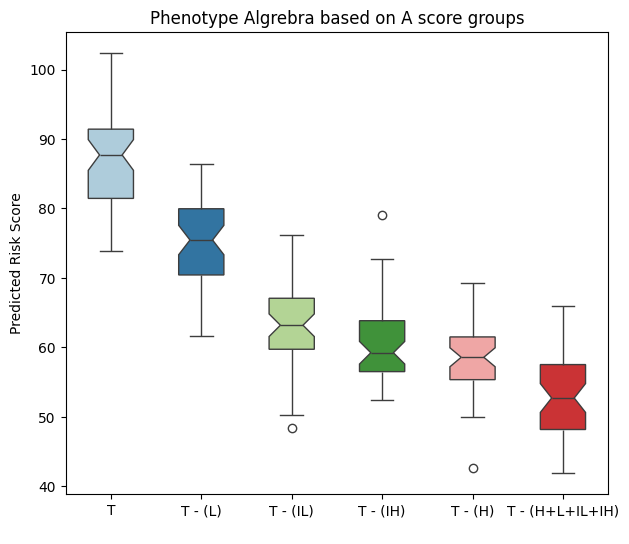

In [20]:
# visualisation
# median_score.sort_values(ascending=True, inplace=True)
predicted_score = predicted_score[median_score.index]
# predicted_sc
plt.figure(figsize=(7,6))
sns.boxplot(
    data=predicted_score, patch_artist=True, notch=True, palette="Paired", dodge=False, width = 0.5
)
plt.xticks(
    ticks=range(len(predicted_score.columns)),
    labels=[label.replace("pseudobulk", "T") + "\n" for label in predicted_score.columns],
    rotation=0,
)
plt.xticks(rotation=0, size=10)
plt.ylabel("Predicted Risk Score")
plt.title("Phenotype Algrebra based on A score groups")
plt.savefig("plots/A_score_phenoalgebra4.png", dpi=300)
plt.show()

In [22]:
# Compute phenotype algebra on VR score derived groups
median_score, predicted_score = sb.SCellBOW_algebra(
    adata_test=adata_target,
    adata_train=adata_train,
    save_dir="pca",
    type="VR_scaled_cat",
    algebra=["L", "IL", "IH", "H"],
    bootstrap_samples=50,
    n_top_features=1000,
).run()

[ 2025-03-20 09:50:08.791000 ] The path to save directory is pca/
[ 2025-03-20 09:50:08.791157 ] Begin SCellBOW: phenotype algebra.


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/SCellBOW/SCellBOW.py:308: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['type'] = y


[ 2025-03-20 09:52:28.110896 ] Begin creating pseudobulk on VR_scaled_cat
[ 2025-03-20 09:52:45.460402 ] Shape of pseudobulk by individual type: (4, 13569)
[ 2025-03-20 09:52:48.071202 ] Adding combined vector for algebra: ['H', 'L', 'IL', 'IH']


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


[2025-03-20 09:52:48.316005]Common gene between survival and target data=12437


...

[ 2025-03-20 09:52:49.047980 ] Tagging the corpora for transfer learning.
[ 2025-03-20 09:52:50.468765 ] All corpuses tagged with length = 159
[ 2025-03-20 09:52:50.469061 ] Updating the vocabulary.
[ 2025-03-20 09:52:50.648647 ] Vocabulary updated.
[ 2025-03-20 09:52:50.648742 ] Start transfer learning on the neural network.
[ 2025-03-20 09:53:24.585614 ] Weights of the neural network calibrated.
[ 2025-03-20 09:53:24.585773 ] Start infering the vectors for target dataset.


  0%|          | 0/159 [00:00<?, ?it/s]

[ 2025-03-20 09:53:52.809334 ] Embedding created with shape : (159, 300)
[ 2025-03-20 09:53:52.809571 ] Start leiden clustering at resolution: 1.0
[ 2025-03-20 09:53:53.392437 ] SCellBOW clustering has been successful!
[ 2025-03-20 09:53:53.405313 ] Finished transfer learning.
[ 2025-03-20 09:53:53.413105 ] Start training the phenotype algebra model.
[ 2025-03-20 09:53:53.413160 ] INFO - SCellBOW: Samples in survival data shape = 153
[ 2025-03-20 09:53:53.413214 ] INFO - SCellBOW: Pseudobulk samples in target data = 6
[ 2025-03-20 09:53:53.413262 ] INFO - SCellBOW: Descriptor class = VR_scaled_cat
[ 2025-03-20 09:53:53.413307 ] INFO - SCellBOW: Train:test split = 80:20


  0%|          | 0/50 [00:00<?, ?it/s]

[ 2025-03-20 09:53:53.423955 ] Epoch 0/50
[ 2025-03-20 09:53:53.929620 ] Epoch 1/50
[ 2025-03-20 09:53:54.432459 ] Epoch 2/50
[ 2025-03-20 09:53:54.913984 ] Epoch 3/50
[ 2025-03-20 09:53:55.374534 ] Epoch 4/50
[ 2025-03-20 09:53:55.889890 ] Epoch 5/50
[ 2025-03-20 09:53:56.399526 ] Epoch 6/50
[ 2025-03-20 09:53:56.888128 ] Epoch 7/50
[ 2025-03-20 09:53:57.397804 ] Epoch 8/50
[ 2025-03-20 09:53:58.010420 ] Epoch 9/50
[ 2025-03-20 09:53:58.545304 ] Epoch 10/50
[ 2025-03-20 09:53:59.020608 ] Epoch 11/50
[ 2025-03-20 09:53:59.556189 ] Epoch 12/50
[ 2025-03-20 09:54:00.053389 ] Epoch 13/50
[ 2025-03-20 09:54:01.055535 ] Epoch 14/50
[ 2025-03-20 09:54:01.581877 ] Epoch 15/50
[ 2025-03-20 09:54:02.093522 ] Epoch 16/50
[ 2025-03-20 09:54:02.636654 ] Epoch 17/50
[ 2025-03-20 09:54:03.092100 ] Epoch 18/50
[ 2025-03-20 09:54:03.576372 ] Epoch 19/50
[ 2025-03-20 09:54:04.069324 ] Epoch 20/50
[ 2025-03-20 09:54:04.571942 ] Epoch 21/50
[ 2025-03-20 09:54:05.055485 ] Epoch 22/50
[ 2025-03-20 09:54:05

In [26]:
median_score

pseudobulk                  82.941167
pseudobulk - (H)            69.254750
pseudobulk - (IH)           60.678333
pseudobulk - (IL)           61.871500
pseudobulk - (L)            67.695583
pseudobulk - (H+L+IL+IH)    56.742667
dtype: float64

In [25]:
median_score.index

Index(['pseudobulk', 'pseudobulk - (H)', 'pseudobulk - (IH)',
       'pseudobulk - (IL)', 'pseudobulk - (L)', 'pseudobulk - (H+L+IL+IH)'],
      dtype='object')

In [27]:
custom_order = [
    "pseudobulk",
    "pseudobulk - (L)",
    "pseudobulk - (IL)",
    "pseudobulk - (IH)",
    "pseudobulk - (H)",
    "pseudobulk - (H+L+IL+IH)",
]


median_score = median_score[custom_order]

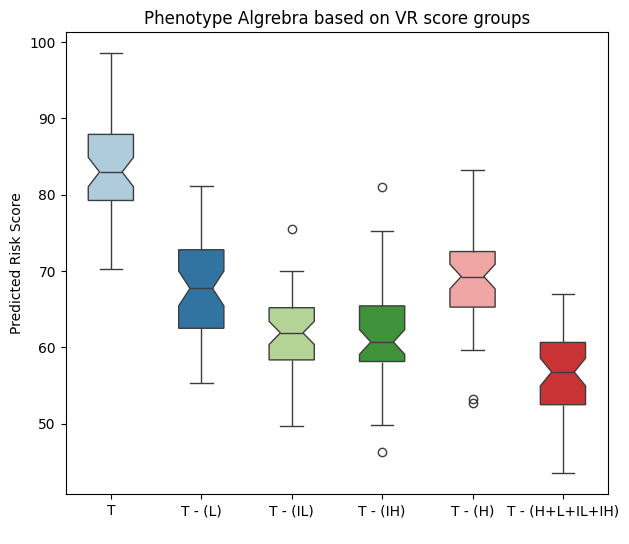

In [28]:
# visualisation
# median_score.sort_values(ascending=True, inplace=True)
predicted_score = predicted_score[median_score.index]
plt.figure(figsize=(7 ,6))
sns.boxplot(
    data=predicted_score, patch_artist=True, notch=True, palette="Paired", dodge=False, width = 0.5
)
plt.xticks(
    ticks=range(len(predicted_score.columns)),
    labels=[label.replace("pseudobulk", "T") + "\n" for label in predicted_score.columns],
    rotation=0,
)
plt.xticks(rotation=0, size=10)
plt.ylabel("Predicted Risk Score")
plt.title("Phenotype Algrebra based on VR score groups")
plt.savefig("plots/VR_score_phenoalgebra4.png", dpi=300)
plt.show()

In [29]:
# Compute phenotype algebra on VAR score subs derived groups
median_score, predicted_score = sb.SCellBOW_algebra(
    adata_test=adata_target,
    adata_train=adata_train,
    save_dir="pca",
    type="VARscore_scaled_subs_cat",
    algebra=["L", "IL", "IH", "H"],
    bootstrap_samples=50,
    n_top_features=1000,
).run()

[ 2025-03-20 09:59:38.280276 ] The path to save directory is pca/
[ 2025-03-20 09:59:38.280496 ] Begin SCellBOW: phenotype algebra.


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/SCellBOW/SCellBOW.py:308: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['type'] = y


[ 2025-03-20 10:02:03.036393 ] Begin creating pseudobulk on VARscore_scaled_subs_cat
[ 2025-03-20 10:02:17.622257 ] Shape of pseudobulk by individual type: (4, 13569)
[ 2025-03-20 10:02:20.590305 ] Adding combined vector for algebra: ['H', 'L', 'IL', 'IH']


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


[2025-03-20 10:02:20.820864]Common gene between survival and target data=12437


...

[ 2025-03-20 10:02:21.537330 ] Tagging the corpora for transfer learning.
[ 2025-03-20 10:02:22.946509 ] All corpuses tagged with length = 159
[ 2025-03-20 10:02:22.946670 ] Updating the vocabulary.
[ 2025-03-20 10:02:23.111575 ] Vocabulary updated.
[ 2025-03-20 10:02:23.111656 ] Start transfer learning on the neural network.
[ 2025-03-20 10:02:55.790687 ] Weights of the neural network calibrated.
[ 2025-03-20 10:02:55.790834 ] Start infering the vectors for target dataset.


  0%|          | 0/159 [00:00<?, ?it/s]

[ 2025-03-20 10:03:22.663234 ] Embedding created with shape : (159, 300)
[ 2025-03-20 10:03:22.663569 ] Start leiden clustering at resolution: 1.0
[ 2025-03-20 10:03:23.147767 ] SCellBOW clustering has been successful!
[ 2025-03-20 10:03:23.169824 ] Finished transfer learning.
[ 2025-03-20 10:03:23.176906 ] Start training the phenotype algebra model.
[ 2025-03-20 10:03:23.176950 ] INFO - SCellBOW: Samples in survival data shape = 153
[ 2025-03-20 10:03:23.177014 ] INFO - SCellBOW: Pseudobulk samples in target data = 6
[ 2025-03-20 10:03:23.177053 ] INFO - SCellBOW: Descriptor class = VARscore_scaled_subs_cat
[ 2025-03-20 10:03:23.177108 ] INFO - SCellBOW: Train:test split = 80:20


  0%|          | 0/50 [00:00<?, ?it/s]

[ 2025-03-20 10:03:23.187477 ] Epoch 0/50
[ 2025-03-20 10:03:23.581624 ] Epoch 1/50
[ 2025-03-20 10:03:24.059961 ] Epoch 2/50
[ 2025-03-20 10:03:24.519586 ] Epoch 3/50
[ 2025-03-20 10:03:24.967928 ] Epoch 4/50
[ 2025-03-20 10:03:25.412485 ] Epoch 5/50
[ 2025-03-20 10:03:25.910777 ] Epoch 6/50
[ 2025-03-20 10:03:26.400513 ] Epoch 7/50
[ 2025-03-20 10:03:26.842284 ] Epoch 8/50
[ 2025-03-20 10:03:27.332745 ] Epoch 9/50
[ 2025-03-20 10:03:27.802499 ] Epoch 10/50
[ 2025-03-20 10:03:28.274527 ] Epoch 11/50
[ 2025-03-20 10:03:28.739372 ] Epoch 12/50
[ 2025-03-20 10:03:29.196789 ] Epoch 13/50
[ 2025-03-20 10:03:29.654754 ] Epoch 14/50
[ 2025-03-20 10:03:30.147685 ] Epoch 15/50
[ 2025-03-20 10:03:30.605369 ] Epoch 16/50
[ 2025-03-20 10:03:31.049411 ] Epoch 17/50
[ 2025-03-20 10:03:31.514496 ] Epoch 18/50
[ 2025-03-20 10:03:31.996288 ] Epoch 19/50
[ 2025-03-20 10:03:32.430678 ] Epoch 20/50
[ 2025-03-20 10:03:32.906849 ] Epoch 21/50
[ 2025-03-20 10:03:33.385251 ] Epoch 22/50
[ 2025-03-20 10:03:33

In [30]:
custom_order = [
    "pseudobulk",
    "pseudobulk - (L)",
    "pseudobulk - (IL)",
    "pseudobulk - (IH)",
    "pseudobulk - (H)",
    "pseudobulk - (H+L+IL+IH)",
]

median_score = median_score[custom_order]

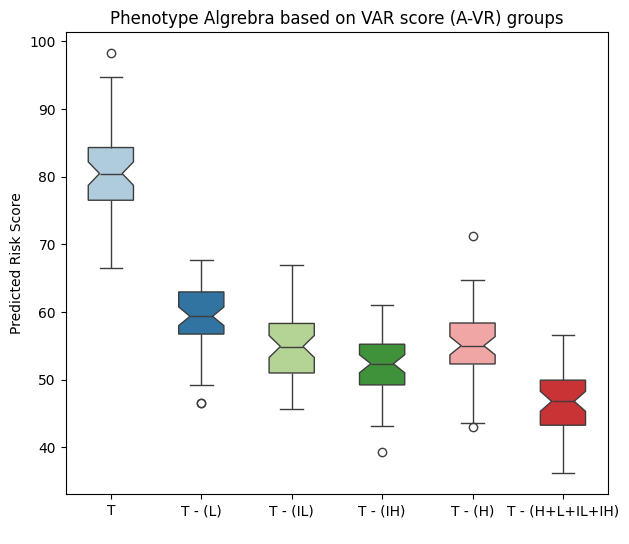

In [31]:
# visualisation of phenotype algebra on VR score derived groups
# median_score.sort_values(ascending=True, inplace=True)
predicted_score = predicted_score[median_score.index]
plt.figure(figsize=(7, 6))
sns.boxplot(
    data=predicted_score,
    patch_artist=True,
    notch=True,
    palette="Paired",
    dodge=False,
    width=0.5,
)
plt.xticks(
    ticks=range(len(predicted_score.columns)),
    labels=[
        label.replace("pseudobulk", "T") + "\n" for label in predicted_score.columns
    ],
    rotation=0,
)
plt.xticks(rotation=0, size=10)
plt.ylabel("Predicted Risk Score")
plt.title("Phenotype Algrebra based on VAR score (A-VR) groups")
plt.savefig("plots/VAR_score_subs_phenoalgebra4.png", dpi=300)
plt.show()

In [32]:
# Compute phenotype algebra on VAR score sum derived groups
median_score, predicted_score = sb.SCellBOW_algebra(
    adata_test=adata_target,
    adata_train=adata_train,
    save_dir="pca",
    type="VARscore_scaled_sum_cat",
    algebra=["L", "IL", "IH", "H"],
    bootstrap_samples=50,
    n_top_features=1000,
).run()

[ 2025-03-20 10:08:33.304879 ] The path to save directory is pca/
[ 2025-03-20 10:08:33.305058 ] Begin SCellBOW: phenotype algebra.


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/SCellBOW/SCellBOW.py:308: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['type'] = y


[ 2025-03-20 10:11:06.275060 ] Begin creating pseudobulk on VARscore_scaled_sum_cat
[ 2025-03-20 10:11:22.208815 ] Shape of pseudobulk by individual type: (4, 13569)
[ 2025-03-20 10:11:25.234886 ] Adding combined vector for algebra: ['H', 'L', 'IL', 'IH']


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


[2025-03-20 10:11:25.487668]Common gene between survival and target data=12437


...

[ 2025-03-20 10:11:26.274256 ] Tagging the corpora for transfer learning.
[ 2025-03-20 10:11:27.683136 ] All corpuses tagged with length = 159
[ 2025-03-20 10:11:27.683281 ] Updating the vocabulary.
[ 2025-03-20 10:11:27.863887 ] Vocabulary updated.
[ 2025-03-20 10:11:27.864015 ] Start transfer learning on the neural network.
[ 2025-03-20 10:12:01.372493 ] Weights of the neural network calibrated.
[ 2025-03-20 10:12:01.372612 ] Start infering the vectors for target dataset.


  0%|          | 0/159 [00:00<?, ?it/s]

[ 2025-03-20 10:12:29.202849 ] Embedding created with shape : (159, 300)
[ 2025-03-20 10:12:29.203119 ] Start leiden clustering at resolution: 1.0
[ 2025-03-20 10:12:29.819215 ] SCellBOW clustering has been successful!
[ 2025-03-20 10:12:29.827933 ] Finished transfer learning.
[ 2025-03-20 10:12:29.836793 ] Start training the phenotype algebra model.
[ 2025-03-20 10:12:29.836848 ] INFO - SCellBOW: Samples in survival data shape = 153
[ 2025-03-20 10:12:29.836906 ] INFO - SCellBOW: Pseudobulk samples in target data = 6
[ 2025-03-20 10:12:29.836953 ] INFO - SCellBOW: Descriptor class = VARscore_scaled_sum_cat
[ 2025-03-20 10:12:29.837005 ] INFO - SCellBOW: Train:test split = 80:20


  0%|          | 0/50 [00:00<?, ?it/s]

[ 2025-03-20 10:12:29.849197 ] Epoch 0/50
[ 2025-03-20 10:12:30.385495 ] Epoch 1/50
[ 2025-03-20 10:12:30.846987 ] Epoch 2/50
[ 2025-03-20 10:12:31.342475 ] Epoch 3/50
[ 2025-03-20 10:12:31.831455 ] Epoch 4/50
[ 2025-03-20 10:12:32.283331 ] Epoch 5/50
[ 2025-03-20 10:12:32.763689 ] Epoch 6/50
[ 2025-03-20 10:12:33.243120 ] Epoch 7/50
[ 2025-03-20 10:12:33.708858 ] Epoch 8/50
[ 2025-03-20 10:12:34.193385 ] Epoch 9/50
[ 2025-03-20 10:12:34.700724 ] Epoch 10/50
[ 2025-03-20 10:12:35.251294 ] Epoch 11/50
[ 2025-03-20 10:12:35.845030 ] Epoch 12/50
[ 2025-03-20 10:12:36.365190 ] Epoch 13/50
[ 2025-03-20 10:12:36.889554 ] Epoch 14/50
[ 2025-03-20 10:12:37.416596 ] Epoch 15/50
[ 2025-03-20 10:12:37.909283 ] Epoch 16/50
[ 2025-03-20 10:12:38.492745 ] Epoch 17/50
[ 2025-03-20 10:12:39.035354 ] Epoch 18/50
[ 2025-03-20 10:12:39.575729 ] Epoch 19/50
[ 2025-03-20 10:12:40.096778 ] Epoch 20/50
[ 2025-03-20 10:12:40.650593 ] Epoch 21/50
[ 2025-03-20 10:12:41.167672 ] Epoch 22/50
[ 2025-03-20 10:12:41

In [33]:
custom_order = [
    "pseudobulk",
    "pseudobulk - (L)",
    "pseudobulk - (IL)",
    "pseudobulk - (IH)",
    "pseudobulk - (H)",
    "pseudobulk - (H+L+IL+IH)",
]

median_score = median_score[custom_order]

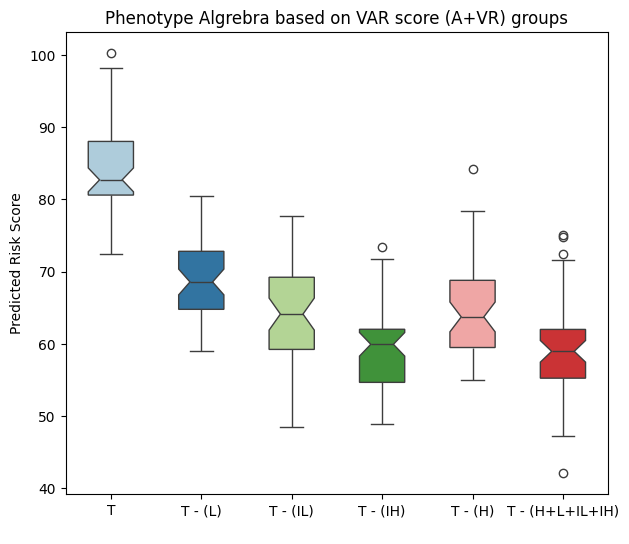

In [34]:
# visualisation of phenotype algebra on VAR score derived groups
# median_score.sort_values(ascending=True, inplace=True)
predicted_score = predicted_score[median_score.index]
plt.figure(figsize=(7, 6))
sns.boxplot(
    data=predicted_score,
    patch_artist=True,
    notch=True,
    palette="Paired",
    dodge=False,
    width=0.5,
)
plt.xticks(
    ticks=range(len(predicted_score.columns)),
    labels=[
        label.replace("pseudobulk", "T") + "\n" for label in predicted_score.columns
    ],
    rotation=0,
)
plt.xticks(rotation=0, size=10)
plt.ylabel("Predicted Risk Score")
plt.title("Phenotype Algrebra based on VAR score (A+VR) groups")
plt.savefig("plots/VAR_score_sum_phenoalgebra4.png", dpi=300)
plt.show()

In [67]:
adata_target.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell', 'sample',
       'percent.mt', 'percent.ribo', 'cell_type', 'malignancy', 'study',
       'patient', 'sex', 'age', 'tumor_type', 'tumor_subtype', 'stage', 'tnm',
       'tumor_site', 'sample_type', 'treated', 'treatment_type',
       'treatment_response', 'treatment_info', 'os', 'pfi', 'sequencing_tech',
       'genome_assembly', 'data_pmid', 'refined_tumor_site', 'study_sample',
       'A_score_raw', 'VR_score_raw', 'A_zscore', 'VR_zscore', 'A_scaled',
       'VR_scaled', 'VARscore_raw_subs', 'VARscore_scaled_subs',
       'VARscore_raw_sum', 'VARscore_scaled_sum', 'A_scaled_cat',
       'VR_scaled_cat', 'VARscore_scaled_subs_cat', 'VARscore_scaled_sum_cat'],
      dtype='object')

In [82]:
# Create patient_sample column
adata_target.obs["patient_sample"] = (
    adata_target.obs["patient"].astype("str")
    + "_"
    + adata_target.obs["sample"].astype("str")
)

In [105]:
adata_target.obs["prefix"] = adata_target.obs["patient_sample"].str.replace(
    r"_GSM\d+", "", regex=True
)

# Create a mapping for new sample names
new_names = {}

# Loop through each unique prefix and assign new names
for prefix in adata_target.obs["prefix"].unique():
    # Get unique samples for this prefix
    unique_samples = adata_target.obs[adata_target.obs["prefix"] == prefix][
        "patient_sample"
    ].unique()
    # Generate new names
    for i, sample in enumerate(unique_samples, start=1):
        new_names[sample] = f"{prefix}_{i}"

# Map the new names back to the DataFrame
adata_target.obs["sample_renamed"] = adata_target.obs["patient_sample"].map(new_names)

# Convert sample_renamed to a categorical variable
adata_target.obs["sample_renamed"] = adata_target.obs["sample_renamed"]
adata_target.obs["sample_renamed"] = pd.Categorical(
    adata_target.obs["sample_renamed"],
    categories=adata_target.obs["sample_renamed"].unique(),
)
# Show the result
print(adata_target.obs[["patient_sample", "sample_renamed"]])

         patient_sample sample_renamed
c705476   p1_GSM5518596           p1_1
c705477   p1_GSM5518596           p1_1
c705478   p1_GSM5518596           p1_1
c705479   p1_GSM5518596           p1_1
c705480   p1_GSM5518596           p1_1
...                 ...            ...
c769366  p18_GSM5518639          p18_1
c769367  p18_GSM5518639          p18_1
c769368  p18_GSM5518639          p18_1
c769369  p18_GSM5518639          p18_1
c769370  p18_GSM5518639          p18_1

[63895 rows x 2 columns]


In [106]:
adata_target.obs["sample_renamed"].unique()


['p1_1', 'p1_2', 'p1_3', 'p2_1', 'p2_2', ..., 'p14_1', 'p15_1', 'p16_1', 'p17_1', 'p18_1']
Length: 34
Categories (34, object): ['p1_1', 'p1_2', 'p1_3', 'p2_1', ..., 'p15_1', 'p16_1', 'p17_1', 'p18_1']

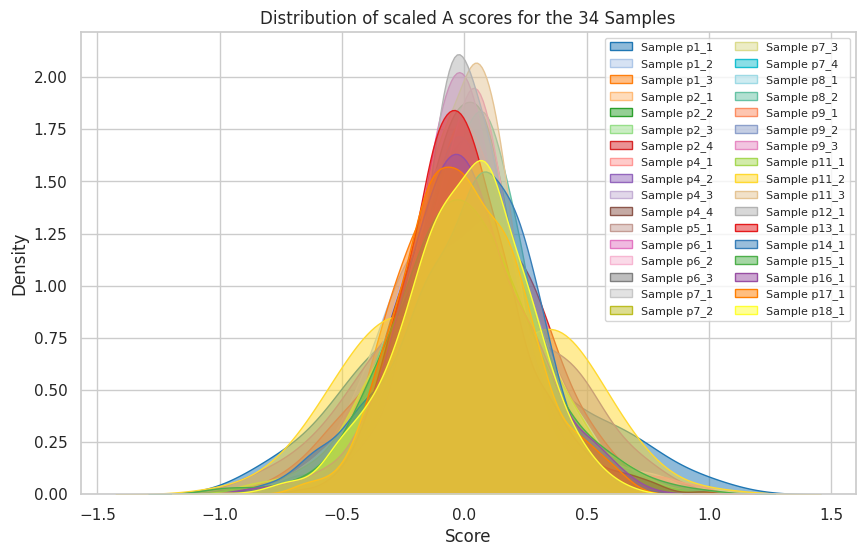

In [126]:
# Plot density plot for A score raw values
plt.figure(figsize=(10, 6))

palette = (
    sns.color_palette("tab20", 20)
    + sns.color_palette("Set2", 8)
    + sns.color_palette("Set1", 6)
)

# Plot KDE for each sample
for (sample, subset), color in zip(adata_target.obs.groupby("sample_renamed"), palette):
    sns.kdeplot(
        subset["A_scaled"],
        color=color,
        label=f"Sample {sample}",
        fill=True,
        alpha=0.5,
    )

plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution of scaled A scores for the 34 Samples")
plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.savefig("plots/A_score_scaled_density_plot.png", dpi=300)  # Save the figure as a PNG
plt.show()

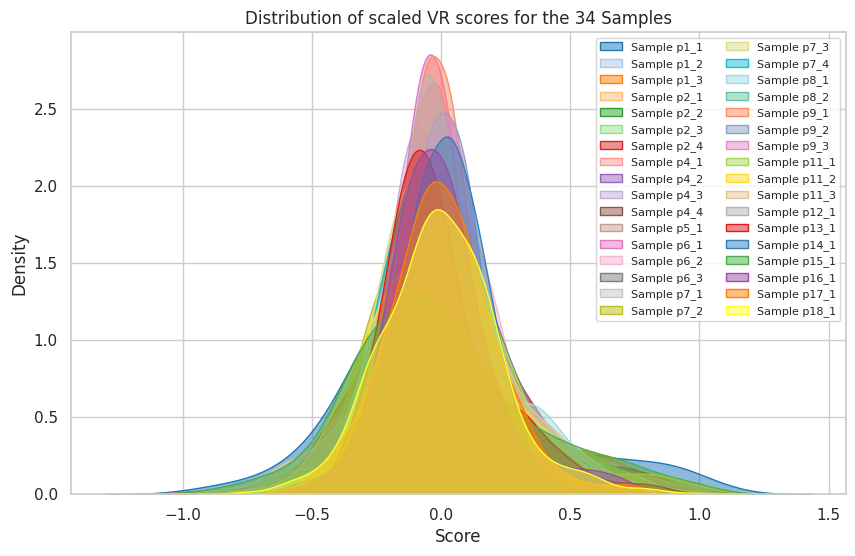

In [135]:
# Plot density plot for VR score raw values
plt.figure(figsize=(10, 6))

palette = (
    sns.color_palette("tab20", 20)
    + sns.color_palette("Set2", 8)
    + sns.color_palette("Set1", 6)
)

# Plot KDE for each sample
for (sample, subset), color in zip(adata_target.obs.groupby("sample_renamed"), palette):
    sns.kdeplot(
        subset["VR_scaled"],
        color=color,
        label=f"Sample {sample}",
        fill=True,
        alpha=0.5,
    )

plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution of scaled VR scores for the 34 Samples")
plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.savefig("plots/VR_score_scaled_density_plot.png", dpi=300)  # Save the figure as a PNG
plt.show()

In [131]:
adata_target.obs.VR_scaled.max()

1.0

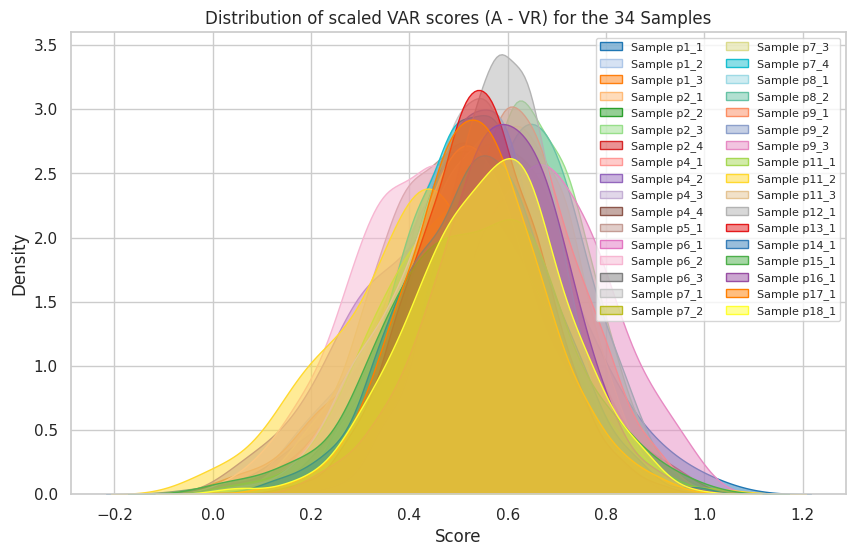

In [132]:
# Plot density plot for VAR score (subs) raw values
plt.figure(figsize=(10, 6))

palette = (
    sns.color_palette("tab20", 20)
    + sns.color_palette("Set2", 8)
    + sns.color_palette("Set1", 6)
)

# Plot KDE for each sample
for (sample, subset), color in zip(adata_target.obs.groupby("sample_renamed"), palette):
    sns.kdeplot(
        subset["VARscore_scaled_subs"],
        color=color,
        label=f"Sample {sample}",
        fill=True,
        alpha=0.5,
    )

plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution of scaled VAR scores (A - VR) for the 34 Samples")
plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.savefig("plots/VARsubs_score_scaled_density_plot.png", dpi=300)  # Save the figure as a PNG
plt.show()

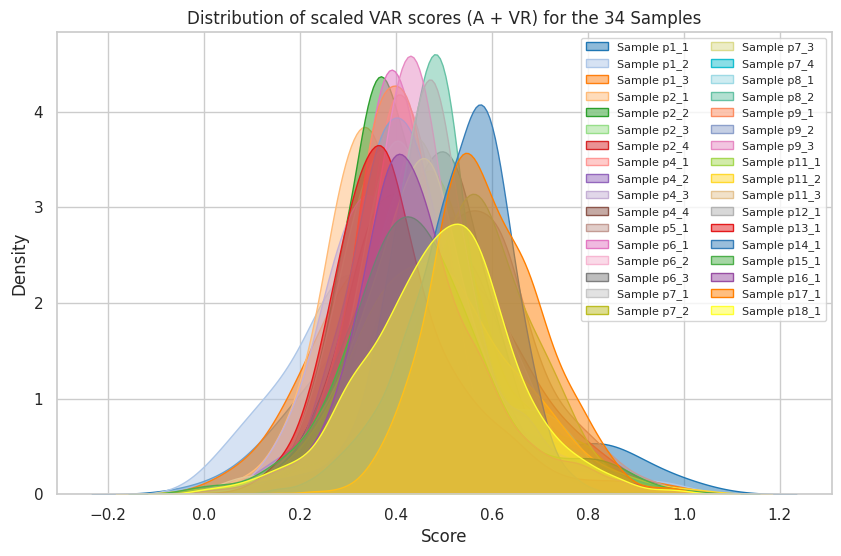

In [134]:
# Plot density plot for VAR score (sum) raw values
plt.figure(figsize=(10, 6))

palette = (
    sns.color_palette("tab20", 20)
    + sns.color_palette("Set2", 8)
    + sns.color_palette("Set1", 6)
)

# Plot KDE for each sample
for (sample, subset), color in zip(adata_target.obs.groupby("sample_renamed"), palette):
    sns.kdeplot(
        subset["VARscore_scaled_sum"],
        color=color,
        label=f"Sample {sample}",
        fill=True,
        alpha=0.5,
    )

plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution of scaled VAR scores (A + VR) for the 34 Samples")
plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1, 1))
plt.savefig("plots/VARsum_score_scaled_density_plot.png", dpi=300)  # Save the figure as a PNG
plt.show()

In [112]:
adata_target.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell', 'sample',
       'percent.mt', 'percent.ribo', 'cell_type', 'malignancy', 'study',
       'patient', 'sex', 'age', 'tumor_type', 'tumor_subtype', 'stage', 'tnm',
       'tumor_site', 'sample_type', 'treated', 'treatment_type',
       'treatment_response', 'treatment_info', 'os', 'pfi', 'sequencing_tech',
       'genome_assembly', 'data_pmid', 'refined_tumor_site', 'study_sample',
       'A_score_raw', 'VR_score_raw', 'A_zscore', 'VR_zscore', 'A_scaled',
       'VR_scaled', 'VARscore_raw_subs', 'VARscore_scaled_subs',
       'VARscore_raw_sum', 'VARscore_scaled_sum', 'A_scaled_cat',
       'VR_scaled_cat', 'VARscore_scaled_subs_cat', 'VARscore_scaled_sum_cat',
       'patient_sample', 'prefix', 'sample_renamed'],
      dtype='object')

/tmp/ipykernel_129675/3333286068.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=score, data=adata_target.obs, ax=axes[i], palette="Set2")
/tmp/ipykernel_129675/3333286068.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=score, data=adata_target.obs, ax=axes[i], palette="Set2")
/tmp/ipykernel_129675/3333286068.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=score, data=adata_target.obs, ax=axes[i], palette="Set2")
/tmp/ipykernel_129675/3333286068.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

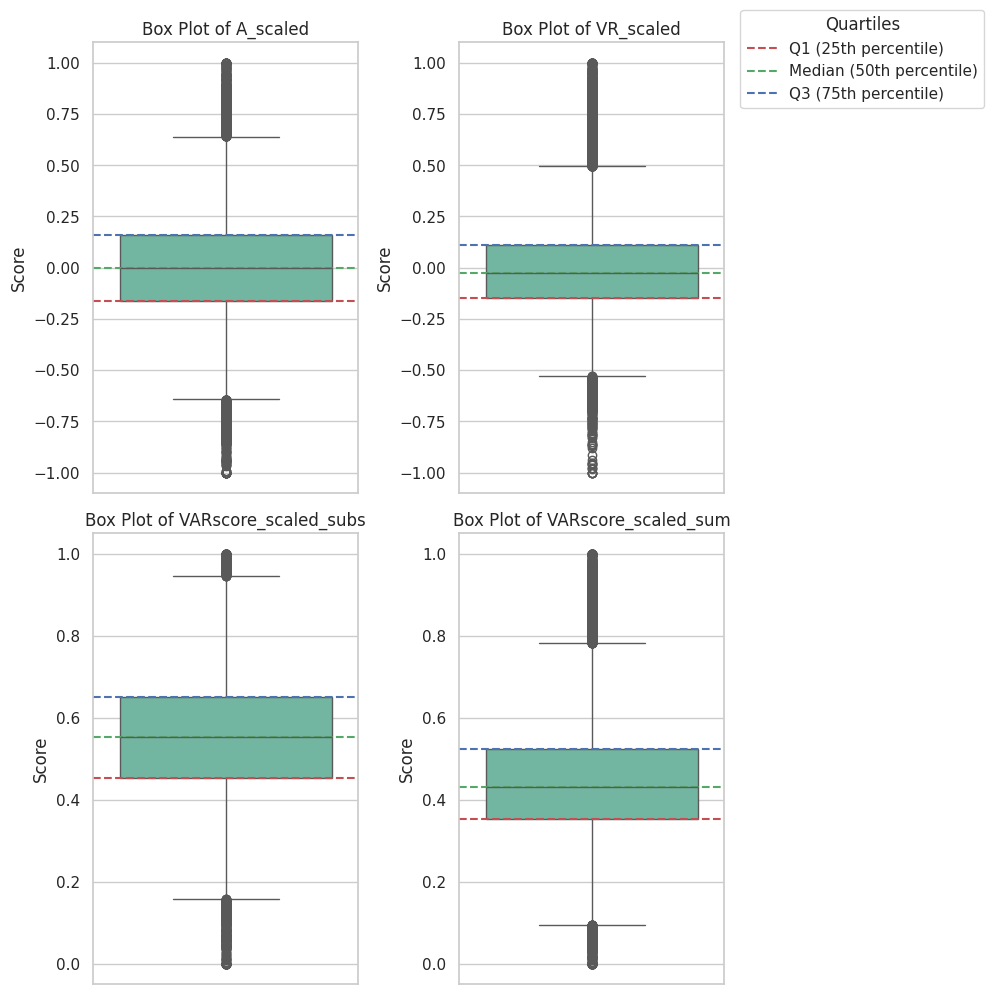

In [125]:
# Boxplot of A, VR, VAR subs and VAR sum scores across all cells
sns.set(style="whitegrid")

# Create a figure with subplots (2 columns, 2 rows)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Flatten axes array for easy indexing
axes = axes.flatten()

# List of score columns to plot
score_columns = [
    "A_scaled",
    "VR_scaled",
    "VARscore_scaled_subs",
    "VARscore_scaled_sum",
]

# Create box plots for each score and indicate quartiles
for i, score in enumerate(score_columns):
    sns.boxplot(y=score, data=adata_target.obs, ax=axes[i], palette="Set2")

    # Calculate quartiles
    Q1 = adata_target.obs[score].quantile(0.25)
    Q2 = adata_target.obs[score].quantile(0.5)  # median
    Q3 = adata_target.obs[score].quantile(0.75)

    # Draw lines for quartiles
    axes[i].axhline(Q1, color="r", linestyle="--", label="Q1 (25th percentile)")
    axes[i].axhline(Q2, color="g", linestyle="--", label="Median (50th percentile)")
    axes[i].axhline(Q3, color="b", linestyle="--", label="Q3 (75th percentile)")

    # Set title and labels
    axes[i].set_title(f"Box Plot of {score}")
    axes[i].set_ylabel("Score")

# Create a common legend outside the plots
handles, labels = axes[0].get_legend_handles_labels()  # Get handles from the first plot
fig.legend(
    handles,
    labels,
    loc="upper right",
    title="Quartiles",
    bbox_to_anchor=(1, 1),
    bbox_transform=fig.transFigure,
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.savefig("plots/boxplot_distribuition_allcells.png", dpi=300)  # Save the figure as a PNG
plt.show()

### Phenotype Algebra on TMZ sensitivy groups

In [10]:
tmz_scores = pd.read_csv(
    "beyondcell_target/bcscore_tmzsigs.tsv", sep="\t"
)
adata_target.obs = adata_target.obs.join(tmz_scores, how="inner")
adata_target.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell,sample,percent.mt,percent.ribo,cell_type,malignancy,study,...,VR_zscore,A_scaled,VR_scaled,VARscore_raw_subs,VARscore_scaled_subs,VARscore_raw_sum,VARscore_scaled_sum,TEMOZOLOMIDE_SENSITIVE_NTAFOULIS,TEMOZOLOMIDE_SENSITIVE_CAIHQ,TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES
c705476,gbm_nourhan_abdelfattah,14608,4194,AAACCTGAGAAGCCCA-1_1_18,GSM5518596,4.186154,7.985450,Glioma,True,gbm_nourhan_abdelfattah,...,0.8030,0.62600,0.3040,0.762,0.766,2.370,0.710,-4.56,-14.88,0.64
c705477,gbm_nourhan_abdelfattah,9025,3015,AAAGCAAAGCTGCAAG-1_1_18,GSM5518596,4.349399,8.608373,Glioma,True,gbm_nourhan_abdelfattah,...,-0.4330,0.35400,-0.1640,1.320,0.912,0.452,0.498,-0.32,-19.60,-0.14
c705478,gbm_nourhan_abdelfattah,11595,3514,AAATGCCCAATTGCTG-1_1_18,GSM5518596,3.504023,8.504399,Glioma,True,gbm_nourhan_abdelfattah,...,1.7400,0.74300,0.6560,0.122,0.598,3.600,0.845,-3.76,-15.46,-6.35
c705479,gbm_nourhan_abdelfattah,3360,1935,AACACGTTCGGCCGAT-1_1_18,GSM5518596,5.526924,2.488004,Glioma,True,gbm_nourhan_abdelfattah,...,-1.4200,-0.30000,-0.5380,0.672,0.742,-2.180,0.208,4.46,2.55,7.38
c705480,gbm_nourhan_abdelfattah,7801,2748,AACCGCGGTAGAGCTG-1_1_18,GSM5518596,3.463663,12.069698,Glioma,True,gbm_nourhan_abdelfattah,...,0.6940,-0.00139,0.2620,-0.697,0.383,0.690,0.524,-2.34,-6.72,-2.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c769366,gbm_nourhan_abdelfattah,4157,2143,TTTGATCGTAGCGCTC-1_44_18,GSM5518639,0.231044,9.976896,Glioma,True,gbm_nourhan_abdelfattah,...,-1.6400,0.20700,-0.3850,2.450,0.895,-0.832,0.414,1.17,-2.08,4.59
c769367,gbm_nourhan_abdelfattah,3677,1778,TTTGATCTCTTGGAAC-1_44_18,GSM5518639,9.142857,2.995074,Glioma,True,gbm_nourhan_abdelfattah,...,-0.3820,-0.33500,-0.0896,-0.928,0.433,-1.690,0.335,2.03,20.78,15.22
c769368,gbm_nourhan_abdelfattah,2175,1214,TTTGGAGTCGTTCGCT-1_44_18,GSM5518639,0.042105,5.557895,Glioma,True,gbm_nourhan_abdelfattah,...,-0.5470,0.23000,-0.1280,1.440,0.758,0.351,0.523,1.46,11.14,4.74
c769369,gbm_nourhan_abdelfattah,3991,2140,TTTGGTTCATCGCTAA-1_44_18,GSM5518639,1.622222,8.844444,Glioma,True,gbm_nourhan_abdelfattah,...,0.0796,0.16200,0.0187,0.554,0.636,0.713,0.556,2.39,-4.88,-2.01


Create three categorical columns representing sensitivity predictions from the three signatures by dividing their respective BCS scores into quartiles

In [11]:
# Define the function to categorize scores
def categorize_quartiles(adata, score_name):
    # Calculate the quartiles
    quartiles = adata.obs[score_name].quantile([0.25, 0.5, 0.75]).values

    def categorize_score(score):
        if score <= quartiles[0]:
            return "L"
        elif score <= quartiles[1]:
            return "IL"
        elif score <= quartiles[2]:
            return "IH"
        else:
            return "H"

    adata.obs[f"{score_name}_cat"] = adata.obs[score_name].apply(categorize_score)


# Apply the categorization function to create a new column
categorize_quartiles(adata_target, "TEMOZOLOMIDE_SENSITIVE_NTAFOULIS")
categorize_quartiles(adata_target, "TEMOZOLOMIDE_SENSITIVE_CAIHQ")
categorize_quartiles(adata_target, "TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES")

adata_target.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell,sample,percent.mt,percent.ribo,cell_type,malignancy,study,...,VARscore_raw_subs,VARscore_scaled_subs,VARscore_raw_sum,VARscore_scaled_sum,TEMOZOLOMIDE_SENSITIVE_NTAFOULIS,TEMOZOLOMIDE_SENSITIVE_CAIHQ,TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES,TEMOZOLOMIDE_SENSITIVE_NTAFOULIS_cat,TEMOZOLOMIDE_SENSITIVE_CAIHQ_cat,TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES_cat
c705476,gbm_nourhan_abdelfattah,14608,4194,AAACCTGAGAAGCCCA-1_1_18,GSM5518596,4.186154,7.985450,Glioma,True,gbm_nourhan_abdelfattah,...,0.762,0.766,2.370,0.710,-4.56,-14.88,0.64,L,L,IH
c705477,gbm_nourhan_abdelfattah,9025,3015,AAAGCAAAGCTGCAAG-1_1_18,GSM5518596,4.349399,8.608373,Glioma,True,gbm_nourhan_abdelfattah,...,1.320,0.912,0.452,0.498,-0.32,-19.60,-0.14,IL,L,IH
c705478,gbm_nourhan_abdelfattah,11595,3514,AAATGCCCAATTGCTG-1_1_18,GSM5518596,3.504023,8.504399,Glioma,True,gbm_nourhan_abdelfattah,...,0.122,0.598,3.600,0.845,-3.76,-15.46,-6.35,L,L,L
c705479,gbm_nourhan_abdelfattah,3360,1935,AACACGTTCGGCCGAT-1_1_18,GSM5518596,5.526924,2.488004,Glioma,True,gbm_nourhan_abdelfattah,...,0.672,0.742,-2.180,0.208,4.46,2.55,7.38,H,IH,H
c705480,gbm_nourhan_abdelfattah,7801,2748,AACCGCGGTAGAGCTG-1_1_18,GSM5518596,3.463663,12.069698,Glioma,True,gbm_nourhan_abdelfattah,...,-0.697,0.383,0.690,0.524,-2.34,-6.72,-2.37,L,IL,IL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c769366,gbm_nourhan_abdelfattah,4157,2143,TTTGATCGTAGCGCTC-1_44_18,GSM5518639,0.231044,9.976896,Glioma,True,gbm_nourhan_abdelfattah,...,2.450,0.895,-0.832,0.414,1.17,-2.08,4.59,IH,IL,H
c769367,gbm_nourhan_abdelfattah,3677,1778,TTTGATCTCTTGGAAC-1_44_18,GSM5518639,9.142857,2.995074,Glioma,True,gbm_nourhan_abdelfattah,...,-0.928,0.433,-1.690,0.335,2.03,20.78,15.22,H,H,H
c769368,gbm_nourhan_abdelfattah,2175,1214,TTTGGAGTCGTTCGCT-1_44_18,GSM5518639,0.042105,5.557895,Glioma,True,gbm_nourhan_abdelfattah,...,1.440,0.758,0.351,0.523,1.46,11.14,4.74,IH,H,H
c769369,gbm_nourhan_abdelfattah,3991,2140,TTTGGTTCATCGCTAA-1_44_18,GSM5518639,1.622222,8.844444,Glioma,True,gbm_nourhan_abdelfattah,...,0.554,0.636,0.713,0.556,2.39,-4.88,-2.01,H,IL,IL


In [12]:
# invoke SCellBOW phenotype algebra on TEMOZOLOMIDE_SENSITIVE_NTAFOULIS_cat groups
median_score, predicted_score = sb.SCellBOW_algebra(
    adata_test=adata_target,
    adata_train=adata_train,
    save_dir="pca",
    type="TEMOZOLOMIDE_SENSITIVE_NTAFOULIS_cat",
    algebra=["L", "IL", "IH", "H"],
    bootstrap_samples=50,
    n_top_features=1000,
).run()

[ 2025-03-24 15:19:03.563998 ] The path to save directory is pca/
[ 2025-03-24 15:19:03.564166 ] Begin SCellBOW: phenotype algebra.


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/SCellBOW/SCellBOW.py:308: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['type'] = y


[ 2025-03-24 15:21:36.521019 ] Begin creating pseudobulk on TEMOZOLOMIDE_SENSITIVE_NTAFOULIS_cat
[ 2025-03-24 15:21:55.382943 ] Shape of pseudobulk by individual type: (4, 13569)
[ 2025-03-24 15:21:58.480760 ] Adding combined vector for algebra: ['IH', 'H', 'L', 'IL']


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


[2025-03-24 15:21:58.755518]Common gene between survival and target data=12437


...

[ 2025-03-24 15:21:59.486098 ] Tagging the corpora for transfer learning.
[ 2025-03-24 15:22:00.934967 ] All corpuses tagged with length = 159
[ 2025-03-24 15:22:00.935320 ] Updating the vocabulary.
[ 2025-03-24 15:22:01.109077 ] Vocabulary updated.
[ 2025-03-24 15:22:01.109173 ] Start transfer learning on the neural network.
[ 2025-03-24 15:22:35.626912 ] Weights of the neural network calibrated.
[ 2025-03-24 15:22:35.627135 ] Start infering the vectors for target dataset.


  0%|          | 0/159 [00:00<?, ?it/s]

[ 2025-03-24 15:23:03.983991 ] Embedding created with shape : (159, 300)
[ 2025-03-24 15:23:03.984531 ] Start leiden clustering at resolution: 1.0
[ 2025-03-24 15:23:16.620684 ] SCellBOW clustering has been successful!
[ 2025-03-24 15:23:16.641839 ] Finished transfer learning.
[ 2025-03-24 15:23:16.650927 ] Start training the phenotype algebra model.
[ 2025-03-24 15:23:16.650994 ] INFO - SCellBOW: Samples in survival data shape = 153
[ 2025-03-24 15:23:16.651055 ] INFO - SCellBOW: Pseudobulk samples in target data = 6
[ 2025-03-24 15:23:16.651105 ] INFO - SCellBOW: Descriptor class = TEMOZOLOMIDE_SENSITIVE_NTAFOULIS_cat
[ 2025-03-24 15:23:16.651151 ] INFO - SCellBOW: Train:test split = 80:20


  0%|          | 0/50 [00:00<?, ?it/s]

[ 2025-03-24 15:23:16.663194 ] Epoch 0/50
[ 2025-03-24 15:23:17.161849 ] Epoch 1/50
[ 2025-03-24 15:23:17.679993 ] Epoch 2/50
[ 2025-03-24 15:23:18.189001 ] Epoch 3/50
[ 2025-03-24 15:23:18.730720 ] Epoch 4/50
[ 2025-03-24 15:23:19.294027 ] Epoch 5/50
[ 2025-03-24 15:23:19.839254 ] Epoch 6/50
[ 2025-03-24 15:23:20.473250 ] Epoch 7/50
[ 2025-03-24 15:23:21.015541 ] Epoch 8/50
[ 2025-03-24 15:23:21.558048 ] Epoch 9/50
[ 2025-03-24 15:23:22.102032 ] Epoch 10/50
[ 2025-03-24 15:23:22.611713 ] Epoch 11/50
[ 2025-03-24 15:23:23.122800 ] Epoch 12/50
[ 2025-03-24 15:23:23.614208 ] Epoch 13/50
[ 2025-03-24 15:23:24.144841 ] Epoch 14/50
[ 2025-03-24 15:23:24.629156 ] Epoch 15/50
[ 2025-03-24 15:23:25.209841 ] Epoch 16/50
[ 2025-03-24 15:23:25.737267 ] Epoch 17/50
[ 2025-03-24 15:23:26.223611 ] Epoch 18/50
[ 2025-03-24 15:23:26.727985 ] Epoch 19/50
[ 2025-03-24 15:23:27.243288 ] Epoch 20/50
[ 2025-03-24 15:23:27.770979 ] Epoch 21/50
[ 2025-03-24 15:23:28.373541 ] Epoch 22/50
[ 2025-03-24 15:23:28

In [13]:
median_score

pseudobulk                  85.279333
pseudobulk - (H)            65.447667
pseudobulk - (IH)           61.632917
pseudobulk - (IL)           60.229000
pseudobulk - (L)            75.001667
pseudobulk - (IH+H+L+IL)    52.345500
dtype: float64

In [15]:
custom_order = [
    "pseudobulk",
    "pseudobulk - (L)",
    "pseudobulk - (IL)",
    "pseudobulk - (IH)",
    "pseudobulk - (H)",
    "pseudobulk - (IH+H+L+IL)",
]


median_score = median_score[custom_order]

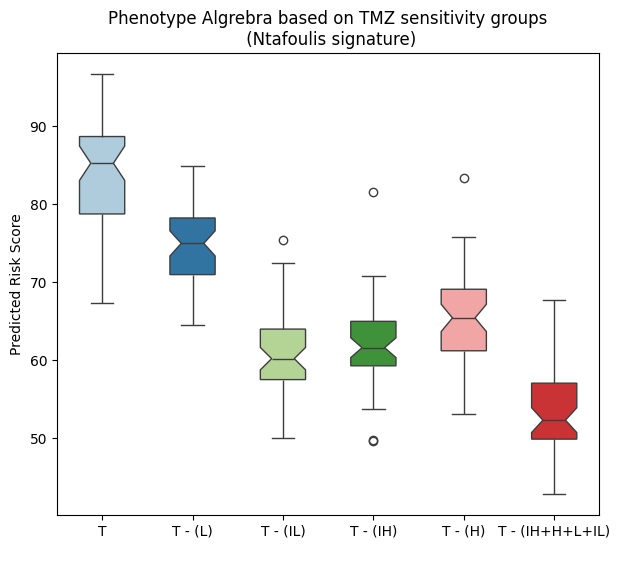

In [16]:
# visualisation of phenotype algebra on VAR score derived groups
# median_score.sort_values(ascending=True, inplace=True)
predicted_score = predicted_score[median_score.index]
plt.figure(figsize=(7, 6))
sns.boxplot(
    data=predicted_score,
    patch_artist=True,
    notch=True,
    palette="Paired",
    dodge=False,
    width=0.5,
)
plt.xticks(
    ticks=range(len(predicted_score.columns)),
    labels=[
        label.replace("pseudobulk", "T") + "\n" for label in predicted_score.columns
    ],
    rotation=0,
)
plt.xticks(rotation=0, size=10)
plt.ylabel("Predicted Risk Score")
plt.title("Phenotype Algrebra based on TMZ sensitivity groups\n (Ntafoulis signature)")
plt.savefig("plots/TMZ_sensitiviy_ntafoulis.png", dpi=300)
plt.show()

In [17]:
# invoke SCellBOW phenotype algebra on TEMOZOLOMIDE_SENSITIVE_CAIHQ groups
median_score, predicted_score = sb.SCellBOW_algebra(
    adata_test=adata_target,
    adata_train=adata_train,
    save_dir="pca",
    type="TEMOZOLOMIDE_SENSITIVE_CAIHQ_cat",
    algebra=["L", "IL", "IH", "H"],
    bootstrap_samples=50,
    n_top_features=1000,
).run()

[ 2025-03-24 15:45:41.164296 ] The path to save directory is pca/
[ 2025-03-24 15:45:41.164463 ] Begin SCellBOW: phenotype algebra.


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/SCellBOW/SCellBOW.py:308: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['type'] = y


[ 2025-03-24 15:47:54.458174 ] Begin creating pseudobulk on TEMOZOLOMIDE_SENSITIVE_CAIHQ_cat
[ 2025-03-24 15:48:07.499289 ] Shape of pseudobulk by individual type: (4, 13569)
[ 2025-03-24 15:48:09.821012 ] Adding combined vector for algebra: ['IH', 'H', 'L', 'IL']
[2025-03-24 15:48:09.999499]Common gene between survival and target data=12437


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


[ 2025-03-24 15:48:10.228514 ] Begin transfer learning.
[ 2025-03-24 15:48:10.268679 ] The path to save directory is ./pca//
[ 2025-03-24 15:48:10.268748 ] Begin SCellBOW: transfer learning.
MinMaxScaler(feature_range=(1, 10))
[ 2025-03-24 15:48:10.295325 ] Creating the corpus.


...

[ 2025-03-24 15:48:10.601165 ] Tagging the corpora for transfer learning.
[ 2025-03-24 15:48:11.710428 ] All corpuses tagged with length = 159
[ 2025-03-24 15:48:11.710586 ] Updating the vocabulary.
[ 2025-03-24 15:48:11.840535 ] Vocabulary updated.
[ 2025-03-24 15:48:11.840598 ] Start transfer learning on the neural network.
[ 2025-03-24 15:48:44.943555 ] Weights of the neural network calibrated.
[ 2025-03-24 15:48:44.943785 ] Start infering the vectors for target dataset.


  0%|          | 0/159 [00:00<?, ?it/s]

[ 2025-03-24 15:49:12.958329 ] Embedding created with shape : (159, 300)
[ 2025-03-24 15:49:12.958696 ] Start leiden clustering at resolution: 1.0
[ 2025-03-24 15:49:13.422390 ] SCellBOW clustering has been successful!
[ 2025-03-24 15:49:13.430820 ] Finished transfer learning.
[ 2025-03-24 15:49:13.437902 ] Start training the phenotype algebra model.
[ 2025-03-24 15:49:13.437949 ] INFO - SCellBOW: Samples in survival data shape = 153
[ 2025-03-24 15:49:13.438000 ] INFO - SCellBOW: Pseudobulk samples in target data = 6
[ 2025-03-24 15:49:13.438052 ] INFO - SCellBOW: Descriptor class = TEMOZOLOMIDE_SENSITIVE_CAIHQ_cat
[ 2025-03-24 15:49:13.438091 ] INFO - SCellBOW: Train:test split = 80:20


  0%|          | 0/50 [00:00<?, ?it/s]

[ 2025-03-24 15:49:13.450010 ] Epoch 0/50
[ 2025-03-24 15:49:13.920216 ] Epoch 1/50
[ 2025-03-24 15:49:14.440760 ] Epoch 2/50
[ 2025-03-24 15:49:14.920190 ] Epoch 3/50
[ 2025-03-24 15:49:15.486690 ] Epoch 4/50
[ 2025-03-24 15:49:16.098458 ] Epoch 5/50
[ 2025-03-24 15:49:16.662084 ] Epoch 6/50
[ 2025-03-24 15:49:17.154037 ] Epoch 7/50
[ 2025-03-24 15:49:17.675975 ] Epoch 8/50
[ 2025-03-24 15:49:18.197599 ] Epoch 9/50
[ 2025-03-24 15:49:18.754839 ] Epoch 10/50
[ 2025-03-24 15:49:19.286989 ] Epoch 11/50
[ 2025-03-24 15:49:19.796656 ] Epoch 12/50
[ 2025-03-24 15:49:20.312454 ] Epoch 13/50
[ 2025-03-24 15:49:20.795324 ] Epoch 14/50
[ 2025-03-24 15:49:21.298120 ] Epoch 15/50
[ 2025-03-24 15:49:21.884190 ] Epoch 16/50
[ 2025-03-24 15:49:22.506277 ] Epoch 17/50
[ 2025-03-24 15:49:23.077680 ] Epoch 18/50
[ 2025-03-24 15:49:23.615761 ] Epoch 19/50
[ 2025-03-24 15:49:24.139055 ] Epoch 20/50
[ 2025-03-24 15:49:24.677781 ] Epoch 21/50
[ 2025-03-24 15:49:25.292107 ] Epoch 22/50
[ 2025-03-24 15:49:25

In [18]:
custom_order = [
    "pseudobulk",
    "pseudobulk - (L)",
    "pseudobulk - (IL)",
    "pseudobulk - (IH)",
    "pseudobulk - (H)",
    "pseudobulk - (IH+H+L+IL)",
]


median_score = median_score[custom_order]

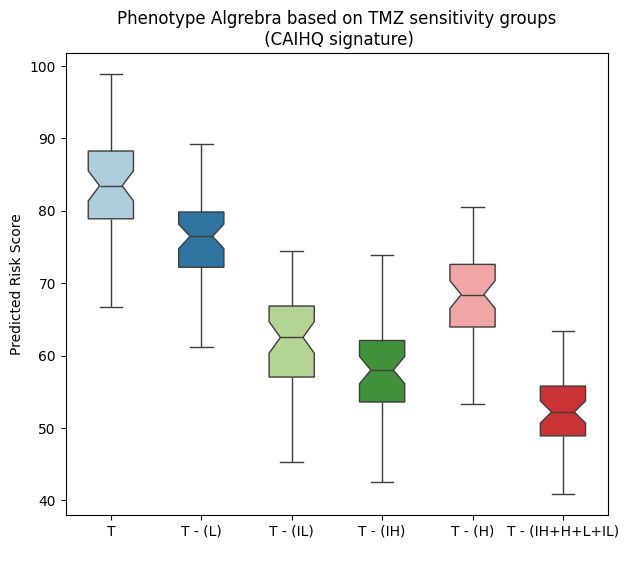

In [19]:
# visualisation of phenotype algebra on VAR score derived groups
# median_score.sort_values(ascending=True, inplace=True)
predicted_score = predicted_score[median_score.index]
plt.figure(figsize=(7, 6))
sns.boxplot(
    data=predicted_score,
    patch_artist=True,
    notch=True,
    palette="Paired",
    dodge=False,
    width=0.5,
)
plt.xticks(
    ticks=range(len(predicted_score.columns)),
    labels=[
        label.replace("pseudobulk", "T") + "\n" for label in predicted_score.columns
    ],
    rotation=0,
)
plt.xticks(rotation=0, size=10)
plt.ylabel("Predicted Risk Score")
plt.title("Phenotype Algrebra based on TMZ sensitivity groups\n (CAIHQ signature)")
plt.savefig("plots/TMZ_sensitiviy_CAIHQ.png", dpi=300)
plt.show()

In [24]:
# invoke SCellBOW phenotype algebra on TEMOZOLOMIDE_SENSITIVE_CAIHQ coding genes groups
median_score, predicted_score = sb.SCellBOW_algebra(
    adata_test=adata_target,
    adata_train=adata_train,
    save_dir="pca",
    type="TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES_cat",
    algebra=["L", "IL", "IH", "H"],
    bootstrap_samples=50,
    n_top_features=1000,
).run()

[ 2025-03-24 16:06:34.029347 ] The path to save directory is pca/
[ 2025-03-24 16:06:34.029528 ] Begin SCellBOW: phenotype algebra.


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/SCellBOW/SCellBOW.py:308: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['type'] = y


[ 2025-03-24 16:08:52.059113 ] Begin creating pseudobulk on TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES_cat
[ 2025-03-24 16:09:05.928329 ] Shape of pseudobulk by individual type: (4, 13569)
[ 2025-03-24 16:09:08.713787 ] Adding combined vector for algebra: ['IH', 'H', 'L', 'IL']


/home/lmgonzalezb/mambaforge/envs/scellbow/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


[2025-03-24 16:09:08.942618]Common gene between survival and target data=12437


...

[ 2025-03-24 16:09:09.661370 ] Tagging the corpora for transfer learning.
[ 2025-03-24 16:09:11.086032 ] All corpuses tagged with length = 159
[ 2025-03-24 16:09:11.086198 ] Updating the vocabulary.
[ 2025-03-24 16:09:11.257218 ] Vocabulary updated.
[ 2025-03-24 16:09:11.257304 ] Start transfer learning on the neural network.
[ 2025-03-24 16:09:45.015750 ] Weights of the neural network calibrated.
[ 2025-03-24 16:09:45.015881 ] Start infering the vectors for target dataset.


  0%|          | 0/159 [00:00<?, ?it/s]

[ 2025-03-24 16:10:08.074838 ] Embedding created with shape : (159, 300)
[ 2025-03-24 16:10:08.075172 ] Start leiden clustering at resolution: 1.0
[ 2025-03-24 16:10:08.553508 ] SCellBOW clustering has been successful!
[ 2025-03-24 16:10:08.561269 ] Finished transfer learning.
[ 2025-03-24 16:10:08.567748 ] Start training the phenotype algebra model.
[ 2025-03-24 16:10:08.567791 ] INFO - SCellBOW: Samples in survival data shape = 153
[ 2025-03-24 16:10:08.567839 ] INFO - SCellBOW: Pseudobulk samples in target data = 6
[ 2025-03-24 16:10:08.567874 ] INFO - SCellBOW: Descriptor class = TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES_cat
[ 2025-03-24 16:10:08.567910 ] INFO - SCellBOW: Train:test split = 80:20


  0%|          | 0/50 [00:00<?, ?it/s]

[ 2025-03-24 16:10:08.577386 ] Epoch 0/50
[ 2025-03-24 16:10:08.984715 ] Epoch 1/50
[ 2025-03-24 16:10:09.530653 ] Epoch 2/50
[ 2025-03-24 16:10:10.068676 ] Epoch 3/50
[ 2025-03-24 16:10:10.626818 ] Epoch 4/50
[ 2025-03-24 16:10:11.153098 ] Epoch 5/50
[ 2025-03-24 16:10:11.673693 ] Epoch 6/50
[ 2025-03-24 16:10:12.179862 ] Epoch 7/50
[ 2025-03-24 16:10:12.728701 ] Epoch 8/50
[ 2025-03-24 16:10:13.225756 ] Epoch 9/50
[ 2025-03-24 16:10:13.750058 ] Epoch 10/50
[ 2025-03-24 16:10:14.344091 ] Epoch 11/50
[ 2025-03-24 16:10:14.972366 ] Epoch 12/50
[ 2025-03-24 16:10:15.571316 ] Epoch 13/50
[ 2025-03-24 16:10:16.071249 ] Epoch 14/50
[ 2025-03-24 16:10:16.553070 ] Epoch 15/50
[ 2025-03-24 16:10:17.133382 ] Epoch 16/50
[ 2025-03-24 16:10:17.715992 ] Epoch 17/50
[ 2025-03-24 16:10:18.281459 ] Epoch 18/50
[ 2025-03-24 16:10:18.859226 ] Epoch 19/50
[ 2025-03-24 16:10:19.369394 ] Epoch 20/50
[ 2025-03-24 16:10:19.869779 ] Epoch 21/50
[ 2025-03-24 16:10:20.361896 ] Epoch 22/50
[ 2025-03-24 16:10:20

In [25]:
median_score

pseudobulk                  79.024583
pseudobulk - (H)            51.492417
pseudobulk - (IH)           53.293167
pseudobulk - (IL)           51.725667
pseudobulk - (L)            59.070167
pseudobulk - (IH+H+L+IL)    48.746500
dtype: float64

In [26]:
custom_order = [
    "pseudobulk",
    "pseudobulk - (L)",
    "pseudobulk - (IL)",
    "pseudobulk - (IH)",
    "pseudobulk - (H)",
    "pseudobulk - (IH+H+L+IL)",
]


median_score = median_score[custom_order]

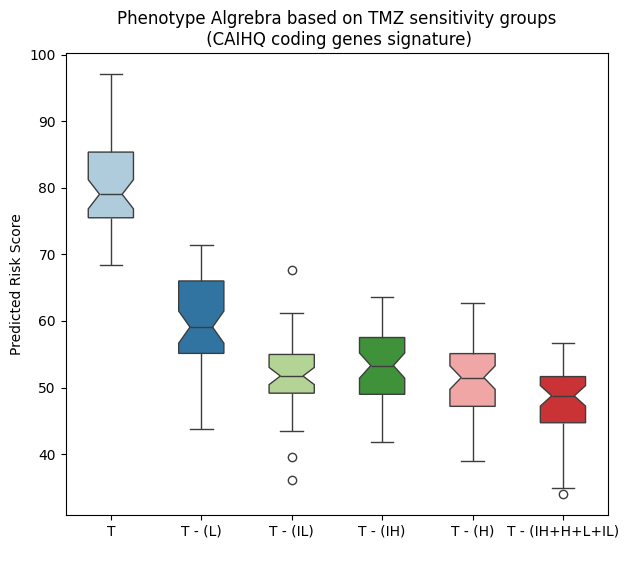

In [27]:
# visualisation of phenotype algebra on VAR score derived groups
# median_score.sort_values(ascending=True, inplace=True)
predicted_score = predicted_score[median_score.index]
plt.figure(figsize=(7, 6))
sns.boxplot(
    data=predicted_score,
    patch_artist=True,
    notch=True,
    palette="Paired",
    dodge=False,
    width=0.5,
)
plt.xticks(
    ticks=range(len(predicted_score.columns)),
    labels=[
        label.replace("pseudobulk", "T") + "\n" for label in predicted_score.columns
    ],
    rotation=0,
)
plt.xticks(rotation=0, size=10)
plt.ylabel("Predicted Risk Score")
plt.title("Phenotype Algrebra based on TMZ sensitivity groups\n (CAIHQ coding genes signature)")
plt.savefig("plots/TMZ_sensitiviy_CAIHQ_coding_genes2.png", dpi=300)
plt.show()

In [28]:
adata_target.obs.TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES_cat.value_counts()

TEMOZOLOMIDE_SENSITIVE_CAIHQ_CODING_GENES_cat
L     15994
IL    15990
H     15972
IH    15939
Name: count, dtype: int64

In [30]:
adata_target.obs["TEMOZOLOMIDE_SENSITIVE_CAIHQ"].quantile(
    [0.25, 0.5, 0.75]
).values

array([-7.74, -0.79,  6.99])